# Semantic Similarity with FAISS

**Audience:** beginners in NLP / vector search.

**Learning objectives**

- See how *semantic similarity* differs from *string matching*.
- Turn text into **embedding vectors** and compare them with a **distance / similarity** measure.
- Use **FAISS** (Facebook AI Similarity Search) to retrieve **nearest neighbors** efficiently over a set of vectors.

**How to work through this lab**

1. Run cells **top to bottom** in order.
2. Read the markdown before each code block — theory is interleaved with practice.
3. If installs succeed but imports still fail, **restart the kernel** and rerun from the top.

**Outputs in this lab**

You will see **pandas tables**, **bar charts**, and **heatmaps** so scores are easier to interpret than raw numbers alone.


## Part 0 — From text to vector space

### Why embeddings?

Two sentences can use **different words** and still **mean the same thing**. Example: *"I love pho"* and *"My favorite Vietnamese noodle soup is pho"*.

**Semantic similarity** measures how close meanings are — usually **approximated** by a geometric relation between two numeric **vectors** (embeddings) produced by a trained model.

### Minimal math intuition

- Each sentence → one vector $\mathbf{e} \in \mathbb{R}^d$ with fixed dimension $d$ (e.g. 384).
- Sentences with similar meaning often have embeddings that are **close** under a chosen metric (**cosine similarity** or **L2 distance**).

> **Note:** Embeddings are only a **semantic approximation** — they depend on training data and context. Always sanity-check on your own examples.


### Step 0.1 — Install libraries (once per environment)

- `sentence-transformers`: turn sentences into embeddings.
- `faiss-cpu`: build an index and run vector search on **CPU**.
- `matplotlib` and `pandas`: plots and tables for intuitive inspection.


In [1]:
# Step 0.1 — Install packages (skip if already installed in this kernel)
import sys
!{sys.executable} -m pip install -q sentence-transformers faiss-cpu numpy matplotlib pandas


### Step 0.2 — Minimal imports

Imports are split into their own cell so import errors immediately tell you which dependency is missing.

- **`matplotlib.pyplot`**: bar charts and heatmaps.
- **`pandas`**: compact tables for retrieval results and metric comparisons.


In [2]:
import numpy as np
import faiss
import matplotlib.pyplot as plt
import pandas as pd

print("NumPy:", np.__version__)
print("FAISS:", getattr(faiss, "__version__", "(version not available)"))
print("Matplotlib:", plt.matplotlib.__version__)
print("Pandas:", pd.__version__)


NumPy: 2.4.4
FAISS: 1.13.2
Matplotlib: 3.10.9
Pandas: 3.0.3


## Bridge — From toy vectors to real embeddings

In **Part 1** you compute cosine / L2 on **3-D** vectors you can still picture. Sentence models output **384-D** vectors — too many dimensions to plot coordinate-wise, so in **Part 2** we use **tables**, **line plots of a few dimensions**, and **heatmaps** instead.


## Part 1 — Semantic similarity "by hand" with NumPy

### What is cosine similarity?

For two non-zero vectors $\mathbf{a}, \mathbf{b}$, **cosine similarity** is the cosine of the angle between them:

$$\text{cos_sim}(\mathbf{a}, \mathbf{b}) = \frac{\mathbf{a} \cdot \mathbf{b}}{\|\mathbf{a}\|_2 \|\mathbf{b}\|_2}$$

- Values lie in $[-1, 1]$ (sentence embeddings often fall in $[0, 1]$ after ReLU / normalization).
- **Closer to 1** → directions align more → often interpreted as *more similar meaning* (heuristic).

Next we compare this to **L2 distance**, which FAISS `IndexFlatL2` uses by default.


In [3]:
def cosine_similarity(a: np.ndarray, b: np.ndarray) -> float:
    a = np.asarray(a, dtype=np.float32).ravel()
    b = np.asarray(b, dtype=np.float32).ravel()
    denom = (np.linalg.norm(a) * np.linalg.norm(b)) + 1e-12
    return float(np.dot(a, b) / denom)


# Toy example: three 3-D vectors
v1 = np.array([1.0, 0.0, 0.0], dtype=np.float32)
v2 = np.array([0.9, 0.1, 0.0], dtype=np.float32)
v3 = np.array([0.0, 1.0, 0.0], dtype=np.float32)

print("cos(v1, v2) =", round(cosine_similarity(v1, v2), 4))
print("cos(v1, v3) =", round(cosine_similarity(v1, v3), 4))


cos(v1, v2) = 0.9939
cos(v1, v3) = 0.0


### Step 1.0 — Plot cosine scores for the toy vectors

The bar chart restates the printed values: $v_1$ is closer to $v_2$ than to $v_3$ under cosine.


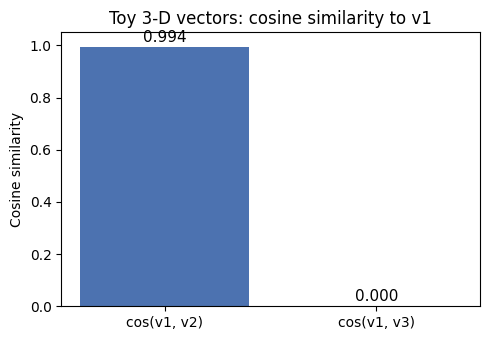

In [4]:
toy_labels = ["cos(v1, v2)", "cos(v1, v3)"]
toy_scores = [cosine_similarity(v1, v2), cosine_similarity(v1, v3)]

fig, ax = plt.subplots(figsize=(5, 3.5))
ax.bar(toy_labels, toy_scores, color=["#4C72B0", "#DD8452"])
ax.set_ylim(0, 1.05)
ax.set_ylabel("Cosine similarity")
for i, s in enumerate(toy_scores):
    ax.text(i, s + 0.02, f"{s:.3f}", ha="center", fontsize=11)
plt.title("Toy 3-D vectors: cosine similarity to v1")
plt.tight_layout()
plt.show()


### Step 1.1 — L2 (Euclidean) distance

$$\|\mathbf{a}-\mathbf{b}\|_2 = \sqrt{\sum_i (a_i-b_i)^2}$$

**FAISS `IndexFlatL2`** returns neighbors with the **smallest L2 distance** to the query vector ("closest" under L2).

If embeddings are **L2-normalized** (norm = 1), L2 and cosine relate more tightly — we revisit that in Part 4.


In [5]:
def l2_distance(a: np.ndarray, b: np.ndarray) -> float:
    a = np.asarray(a, dtype=np.float32).ravel()
    b = np.asarray(b, dtype=np.float32).ravel()
    return float(np.linalg.norm(a - b))


print("L2(v1, v2) =", round(l2_distance(v1, v2), 4))
print("L2(v1, v3) =", round(l2_distance(v1, v3), 4))


L2(v1, v2) = 0.1414
L2(v1, v3) = 1.4142


### Step 1.2 — Compare cosine and L2 side by side

Smaller L2 means **closer** in Euclidean space. Cosine ignores vector length; L2 does not — later, normalization makes rankings more aligned.


,pair,cosine,L2
0,v1 vs v2,0.9939,0.1414
1,v1 vs v3,0.0000,1.4142


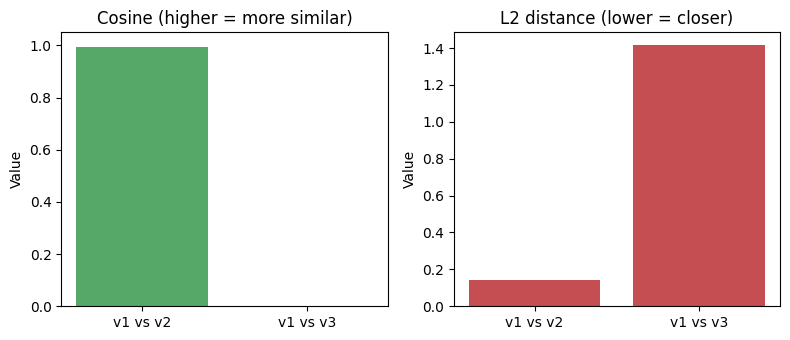

In [6]:
from IPython.display import display

metrics = pd.DataFrame(
    [
        {"pair": "v1 vs v2", "cosine": cosine_similarity(v1, v2), "L2": l2_distance(v1, v2)},
        {"pair": "v1 vs v3", "cosine": cosine_similarity(v1, v3), "L2": l2_distance(v1, v3)},
    ]
)
display(metrics.round(4))

fig, axes = plt.subplots(1, 2, figsize=(8, 3.5))
axes[0].bar(metrics["pair"], metrics["cosine"], color="#55A868")
axes[0].set_ylim(0, 1.05)
axes[0].set_title("Cosine (higher = more similar)")
axes[1].bar(metrics["pair"], metrics["L2"], color="#C44E52")
axes[1].set_title("L2 distance (lower = closer)")
for ax in axes:
    ax.set_ylabel("Value")
plt.tight_layout()
plt.show()


## Part 2 — Sentence embeddings with Sentence Transformers

### Model `all-MiniLM-L6-v2`

- Lightweight; runs comfortably on **CPU** for this lab.
- Produces a **384-dimensional** vector per sentence (or short paragraph).

**Intuitive pipeline:** `text` → tokenizer → neural network → pooling → vector.


In [7]:
from sentence_transformers import SentenceTransformer

MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"
encoder = SentenceTransformer(MODEL_NAME)
print("Model loaded:", MODEL_NAME)


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Model loaded: sentence-transformers/all-MiniLM-L6-v2


### Interlude — Lexical overlap vs embedding cosine

**Lexical** overlap (here: **Jaccard** on word sets) only sees shared tokens. **Semantic** similarity uses embeddings, so paraphrases can score high even when word overlap is low.

The next cell builds a **table** and a **grouped bar chart** for three hand-picked pairs.


,pair,sentence_a,sentence_b,jaccard_words,cosine_emb
0,"Same scene, different words",The cat sat on the mat.,A cat was sitting on a mat.,0.375,0.942
1,"Related topic, few shared words",I love machine learning.,Neural networks are fascinating.,0.000,0.671
2,Unrelated,Stock markets fell today.,I baked bread this morning.,0.000,0.097


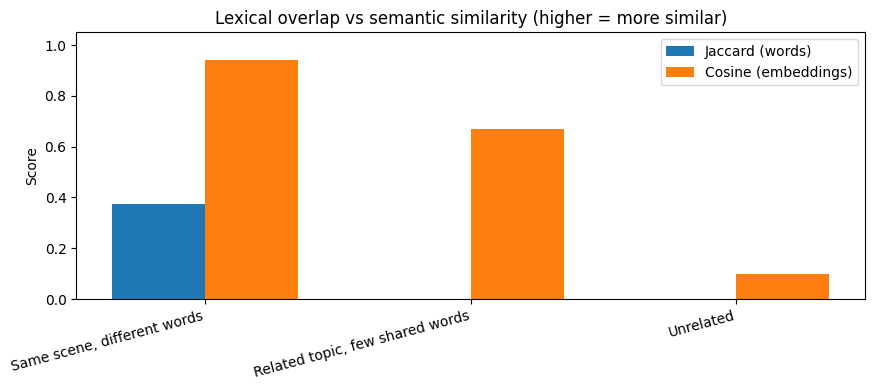

In [8]:
from IPython.display import display


def jaccard_words(s1: str, s2: str) -> float:
    def tok(s: str):
        return set(s.lower().replace(".", " ").split())

    a, b = tok(s1), tok(s2)
    if not a and not b:
        return 1.0
    return len(a & b) / (len(a | b) + 1e-12)


pairs = [
    ("The cat sat on the mat.", "A cat was sitting on a mat.", "Same scene, different words"),
    ("I love machine learning.", "Neural networks are fascinating.", "Related topic, few shared words"),
    ("Stock markets fell today.", "I baked bread this morning.", "Unrelated"),
]

rows = []
for s1, s2, note in pairs:
    e1 = encoder.encode(s1, convert_to_numpy=True, normalize_embeddings=True)
    e2 = encoder.encode(s2, convert_to_numpy=True, normalize_embeddings=True)
    rows.append(
        {
            "pair": note,
            "sentence_a": s1[:44] + ("..." if len(s1) > 44 else ""),
            "sentence_b": s2[:44] + ("..." if len(s2) > 44 else ""),
            "jaccard_words": round(jaccard_words(s1, s2), 3),
            "cosine_emb": round(cosine_similarity(e1, e2), 3),
        }
    )

df_pairs = pd.DataFrame(rows)
display(df_pairs)

labels = [r["pair"] for r in rows]
x = np.arange(len(labels))
w = 0.35
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(x - w / 2, df_pairs["jaccard_words"], width=w, label="Jaccard (words)")
ax.bar(x + w / 2, df_pairs["cosine_emb"], width=w, label="Cosine (embeddings)")
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=15, ha="right")
ax.set_ylim(0, 1.05)
ax.set_ylabel("Score")
ax.set_title("Lexical overlap vs semantic similarity (higher = more similar)")
ax.legend()
plt.tight_layout()
plt.show()


### Step 2.1 — Encode a single sentence

`encode` returns NumPy `float32` arrays — the usual choice for FAISS on CPU.


In [9]:
sent_a = "I enjoy studying machine learning."
sent_b = "I love learning about ML."
sent_c = "It is raining heavily today."

emb_a = encoder.encode(sent_a, convert_to_numpy=True, normalize_embeddings=False)
emb_b = encoder.encode(sent_b, convert_to_numpy=True, normalize_embeddings=False)
emb_c = encoder.encode(sent_c, convert_to_numpy=True, normalize_embeddings=False)

print("Shape:", emb_a.shape)  # expect (384,)
print("cos(a,b) =", round(cosine_similarity(emb_a, emb_b), 4))
print("cos(a,c) =", round(cosine_similarity(emb_a, emb_c), 4))


Shape: (384,)
cos(a,b) = 0.6554
cos(a,c) = -0.0332


### Step 2.1a — Inspect one embedding vector

Each sentence becomes a long list of numbers. The **norm** (length) is useful when you compare L2 vs cosine behavior.


emb_a: shape=(384,), norm=1.0000, min=-0.1385, max=0.1383
  first 12 dims: [-0.0106 -0.067   0.0465  0.0152  0.0546 -0.0608  0.0047  0.0034 -0.0066
  0.0191 -0.0706  0.0367]
emb_b: shape=(384,), norm=1.0000, min=-0.1843, max=0.1311
  first 12 dims: [ 0.0454 -0.0794  0.0275  0.0072  0.0153 -0.0421  0.0012  0.0056  0.0617
  0.0202  0.0195  0.0507]
emb_c: shape=(384,), norm=1.0000, min=-0.1371, max=0.1594
  first 12 dims: [-0.0091  0.0196  0.0965  0.0368  0.0634 -0.0582  0.0598 -0.0468 -0.0588
  0.0424 -0.0846 -0.0485]


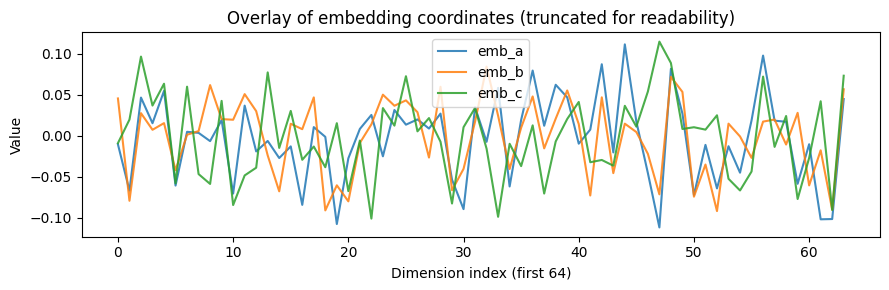

In [10]:
def summarize_vector(name: str, v: np.ndarray) -> None:
    v = np.asarray(v, dtype=np.float32).ravel()
    print(f"{name}: shape={v.shape}, norm={np.linalg.norm(v):.4f}, min={v.min():.4f}, max={v.max():.4f}")
    print("  first 12 dims:", np.round(v[:12], 4))


summarize_vector("emb_a", emb_a)
summarize_vector("emb_b", emb_b)
summarize_vector("emb_c", emb_c)

fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(emb_a[:64], label="emb_a", alpha=0.85)
ax.plot(emb_b[:64], label="emb_b", alpha=0.85)
ax.plot(emb_c[:64], label="emb_c", alpha=0.85)
ax.set_xlabel("Dimension index (first 64)")
ax.set_ylabel("Value")
ax.set_title("Overlay of embedding coordinates (truncated for readability)")
ax.legend()
plt.tight_layout()
plt.show()


### Step 2.1b — Pairwise cosine matrix (three sentences)

A **heatmap** shows all pairwise cosines at once. The diagonal is 1 (each sentence with itself). Off-diagonal values compare different sentences.


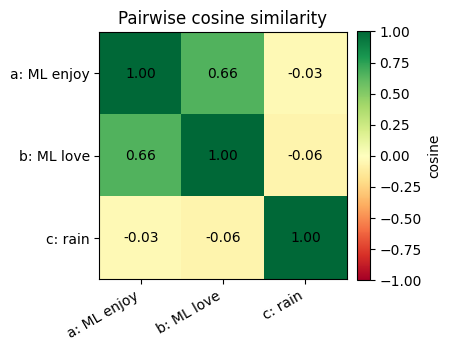

In [11]:
labels_abc = ["a: ML enjoy", "b: ML love", "c: rain"]
E = np.stack([emb_a, emb_b, emb_c], axis=0).astype(np.float32)
dot = E @ E.T
norms = np.linalg.norm(E, axis=1, keepdims=True)
cos_mat = dot / (norms @ norms.T + 1e-12)

fig, ax = plt.subplots(figsize=(4.5, 4))
im = ax.imshow(cos_mat, vmin=-1, vmax=1, cmap="RdYlGn")
ax.set_xticks(range(3))
ax.set_yticks(range(3))
ax.set_xticklabels(labels_abc, rotation=30, ha="right")
ax.set_yticklabels(labels_abc)
for i in range(3):
    for j in range(3):
        ax.text(j, i, f"{cos_mat[i, j]:.2f}", ha="center", va="center", color="black", fontsize=10)
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="cosine")
plt.title("Pairwise cosine similarity")
plt.tight_layout()
plt.show()


### Step 2.2 — Encode many sentences (batch)

Batching lets the library parallelize work — important when the corpus is large.


In [12]:
corpus = [
    "Docker packages applications into portable units.",
    "Containers help deploy consistently across environments.",
    "Kubernetes orchestrates many containers on a cluster.",
    "I want to learn how to cook beef pho.",
]

X = encoder.encode(corpus, convert_to_numpy=True, normalize_embeddings=False)
X = np.asarray(X, dtype=np.float32)
print("Matrix shape [N, d]:", X.shape)


Matrix shape [N, d]: (4, 384)


### Step 2.3 — Corpus similarity heatmap

Each cell $(i,j)$ is cosine similarity between corpus sentence $i$ and $j$. Scan **off-diagonal** cells: DevOps-related lines should score higher with each other than with the cooking line.


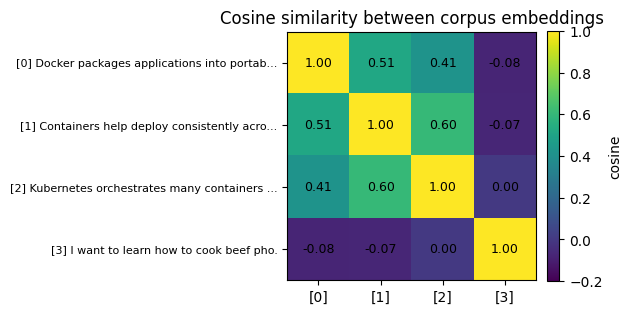

In [13]:
def cosine_sim_matrix(emb: np.ndarray) -> np.ndarray:
    emb = np.asarray(emb, dtype=np.float32)
    dot = emb @ emb.T
    norms = np.linalg.norm(emb, axis=1, keepdims=True)
    return dot / (norms @ norms.T + 1e-12)


S = cosine_sim_matrix(X)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(S, vmin=-0.2, vmax=1.0, cmap="viridis")
ax.set_xticks(range(len(corpus)))
ax.set_yticks(range(len(corpus)))
short = [c[:40] + "..." if len(c) > 40 else c for c in corpus]
ax.set_xticklabels([f"[{i}]" for i in range(len(corpus))])
ax.set_yticklabels([f"[{i}] " + short[i] for i in range(len(corpus))], fontsize=8)
for i in range(len(corpus)):
    for j in range(len(corpus)):
        ax.text(j, i, f"{S[i, j]:.2f}", ha="center", va="center", color="black", fontsize=9)
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="cosine")
plt.title("Cosine similarity between corpus embeddings")
plt.tight_layout()
plt.show()


### From similarity matrix to fast search

The corpus **heatmap** materializes every pairwise score — $\mathcal{O}(N^2)$ work if you repeat it naively for each query. **FAISS** answers *nearest neighbors for one query vector* by scanning the stored database once per query with `IndexFlatL2` (still $\mathcal{O}(N)$ per query, but structured and easy to swap for faster approximate indexes later).


## Part 3 — FAISS basics: `IndexFlatL2`

### What does FAISS do?

FAISS provides an **index** data structure over a vector database to answer:

> Given a query vector $\mathbf{q}$, which **top‑k** database vectors are closest to $\mathbf{q}$?

`IndexFlatL2` is a **flat** index: no compression, no clustering — it **scans every vector**. That is simple to understand and debug, and it is a strong baseline for small / medium $N$.

### Matrix layout for FAISS

- FAISS expects **`float32`** matrices with shape **`(N, d)`** — each **row** is one vector.


In [14]:
assert X.dtype == np.float32
N, d = X.shape
index_l2 = faiss.IndexFlatL2(d)
index_l2.add(X)
print("Is trained?", index_l2.is_trained)  # FlatL2: no training step
print("#vectors in index:", index_l2.ntotal)


Is trained? True
#vectors in index: 4


### Step 3.0 — What `add` did (no training for `Flat`)

`IndexFlatL2` stores every row of $X$ as-is. `ntotal` counts stored vectors — it should match $N$, the number of corpus rows.


In [15]:
from IPython.display import display

summary = pd.DataFrame([{"N (rows)": N, "d (dims)": d, "index.ntotal": index_l2.ntotal, "dtype": str(X.dtype)}])
display(summary)


,N (rows),d (dims),index.ntotal,dtype
0,4,384,4,float32


### Step 3.1 — Query top‑k

`search` takes a query matrix of shape **`(n_query, d)`** and returns **distances** plus **row indices** into the index.


In [16]:
query_text = "What orchestrates microservices across many servers?"
q = encoder.encode([query_text], convert_to_numpy=True, normalize_embeddings=False)
q = np.asarray(q, dtype=np.float32)

k = 2
distances, indices = index_l2.search(q, k)

print("Query:", query_text)
for rank, (idx, dist) in enumerate(zip(indices[0], distances[0]), start=1):
    print(f"#{rank} idx={idx} L2^2={dist:.4f} :: {corpus[idx]}")


Query: What orchestrates microservices across many servers?
#1 idx=2 L2^2=0.9374 :: Kubernetes orchestrates many containers on a cluster.
#2 idx=1 L2^2=1.2193 :: Containers help deploy consistently across environments.


### Step 3.2 — Visualize FAISS L2 scores for top‑k

Lower **squared L2** is better (closer). Bars make it easy to compare the margin between rank 1 and rank 2.


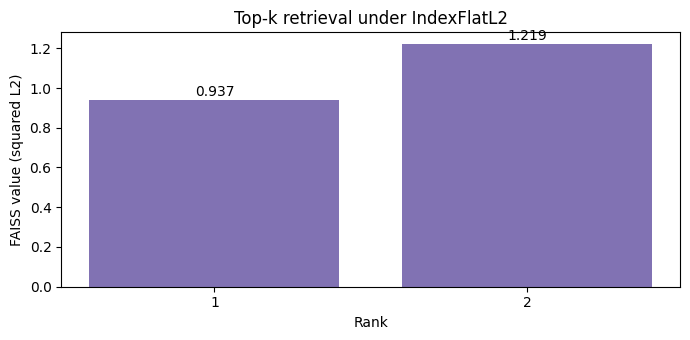

,rank,corpus_idx,L2_squared,text
0,1,2,0.937423,Kubernetes orchestrates many containers on a c...
1,2,1,1.219274,Containers help deploy consistently across env...


In [17]:
from IPython.display import display

ranks = np.arange(1, k + 1)
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.bar(ranks.astype(str), distances[0], color="#8172B3")
ax.set_xlabel("Rank")
ax.set_ylabel("FAISS value (squared L2)")
ax.set_title("Top-k retrieval under IndexFlatL2")
dmax = float(np.max(distances[0])) + 1e-9
for i, dist in enumerate(distances[0]):
    ax.text(i, dist + 0.02 * dmax, f"{dist:.3f}", ha="center", fontsize=10)
plt.tight_layout()
plt.show()

hits = pd.DataFrame(
    {
        "rank": list(range(1, k + 1)),
        "corpus_idx": indices[0].tolist(),
        "L2_squared": distances[0].tolist(),
        "text": [corpus[i] for i in indices[0]],
    }
)
display(hits)


### Theory note: FAISS returns **squared** L2

For `IndexFlatL2`, the reported value is proportional to **squared** L2 (skipping the square root saves compute). Rankings are identical to true L2 distance.


In [18]:
i = int(indices[0][0])
manual = float(np.sum((q[0] - X[i]) ** 2))
print("FAISS dist[0]:", float(distances[0][0]))
print("Manual ||q-x||^2:", manual)


FAISS dist[0]: 0.9374226331710815
Manual ||q-x||^2: 0.9374225735664368


## Part 4 — Cosine search with FAISS: `IndexFlatIP` (inner product)

### L2 normalization + inner product

If $\|\mathbf{a}\|_2=\|\mathbf{b}\|_2=1$, then $\mathbf{a}\cdot\mathbf{b} = \cos\theta$ — exactly **cosine similarity**.

So, **maximizing cosine** between unit vectors is the same as **maximizing inner product**.

FAISS `IndexFlatIP` retrieves vectors with the **largest inner product** against the query — use it when both the database and the query are **normalized**.


In [19]:
Xn = encoder.encode(corpus, convert_to_numpy=True, normalize_embeddings=True)
Xn = np.asarray(Xn, dtype=np.float32)
qn = encoder.encode([query_text], convert_to_numpy=True, normalize_embeddings=True)
qn = np.asarray(qn, dtype=np.float32)

index_ip = faiss.IndexFlatIP(d)
index_ip.add(Xn)
scores, idx_ip = index_ip.search(qn, k=2)

print("Query:", query_text)
for rank, (idx, score) in enumerate(zip(idx_ip[0], scores[0]), start=1):
    print(f"#{rank} idx={idx} IP={score:.4f} :: {corpus[idx]}")


Query: What orchestrates microservices across many servers?
#1 idx=2 IP=0.5313 :: Kubernetes orchestrates many containers on a cluster.
#2 idx=1 IP=0.3904 :: Containers help deploy consistently across environments.


### Step 4.1 — Match manual cosine to inner product

For unit-norm vectors, `cosine_similarity` and the scalar inner product agree up to tiny floating-point noise.


In [20]:
j = int(idx_ip[0][0])
cos_manual = cosine_similarity(qn[0], Xn[j])
ip_manual = float(np.dot(qn[0], Xn[j]))
print("cos manual:", round(cos_manual, 6))
print("IP manual:", round(ip_manual, 6))
print("FAISS IP:", round(float(scores[0][0]), 6))


cos manual: 0.531289
IP manual: 0.531289
FAISS IP: 0.531289


### Step 4.2 — Compare rankings: L2 vs inner product (cosine)

Both indexes often agree on **rank 1**, but ordering can differ when vectors have different lengths (not normalized) or when scores are close.

The chart uses **fresh** top‑3 searches so bar lengths always match three ranks.


,rank,L2_indexFlatL2,IP_indexFlatIP,same_hit
0,1,2,2,True
1,2,1,1,True
2,3,0,0,True


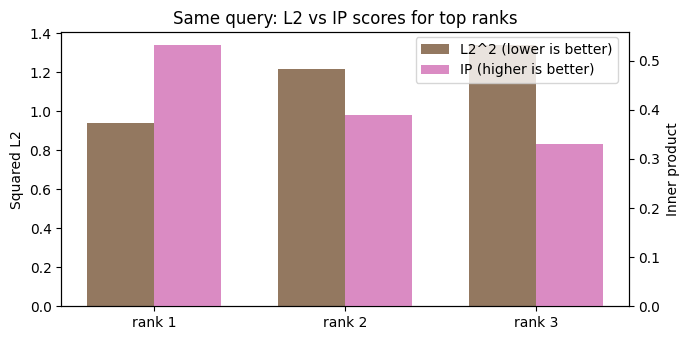

In [21]:
from IPython.display import display

k3 = min(3, N)
dist_top, idx_l2_top = index_l2.search(q, k3)
scores_top, idx_ip_top = index_ip.search(qn, k3)

compare = pd.DataFrame(
    {
        "rank": list(range(1, k3 + 1)),
        "L2_indexFlatL2": idx_l2_top[0].tolist(),
        "IP_indexFlatIP": idx_ip_top[0].tolist(),
    }
)
compare["same_hit"] = compare["L2_indexFlatL2"] == compare["IP_indexFlatIP"]
display(compare)

fig, ax = plt.subplots(figsize=(7, 3.5))
w = 0.35
x = np.arange(k3)
ax.bar(x - w / 2, dist_top[0], width=w, label="L2^2 (lower is better)", color="#937860")
ax2 = ax.twinx()
ax2.bar(x + w / 2, scores_top[0], width=w, label="IP (higher is better)", color="#DA8BC3")
ax.set_xticks(x)
ax.set_xticklabels([f"rank {i+1}" for i in range(k3)])
ax.set_ylabel("Squared L2")
ax2.set_ylabel("Inner product")
ax.set_title("Same query: L2 vs IP scores for top ranks")
fig.legend(loc="upper right", bbox_to_anchor=(0.9, 0.9))
plt.tight_layout()
plt.show()


### Step 4.3 — In-place L2 normalization with `faiss.normalize_L2`

SentenceTransformers can normalize for you (`normalize_embeddings=True`). FAISS also exposes `faiss.normalize_L2`, which modifies rows **in place** to unit length — useful when you already have a matrix in FAISS layout.


In [22]:
X_copy = X.copy()
faiss.normalize_L2(X_copy)
row_norms = np.linalg.norm(X_copy, axis=1)
print("Row L2 norms after faiss.normalize_L2 (should be ~1):", np.round(row_norms, 4))


Row L2 norms after faiss.normalize_L2 (should be ~1): [1. 1. 1. 1.]


## Part 5 — Mini exercise (your turn)

1. Add 5–10 **English** sentences to `corpus` about **one topic** you choose (e.g. programming, travel, medicine).
2. Write a `query_text` that is **paraphrased** — not copied verbatim from any corpus line.
3. Compare **top‑3** results from `IndexFlatL2` (no normalization) vs `IndexFlatIP` (normalized embeddings).
4. Write 2–3 sentences: are the hits sensible? When might the two indexes disagree on ranking?

> **Tip:** Very short sentences or rare words can produce misleading embeddings — that is a **model limitation**, not a FAISS bug.


In [23]:
# TODO — your workspace
my_corpus = [
    # "...",
]

my_query = "..."

# When ready, uncomment and run:
# X_my = encoder.encode(my_corpus, convert_to_numpy=True, normalize_embeddings=False).astype(np.float32)
# ...
print("Complete the TODO above with your own corpus and query.")


Complete the TODO above with your own corpus and query.


## Part 6 — Further reading (optional for a short lab)

- **IVF**, **PQ**, **HNSW**: approximate indexes that reduce cost when $N$ is huge — they need tuning and can miss true nearest neighbors.
- **Metadata filtering:** FAISS is vector-only; production systems often pair it with a database or rules for time range, permissions, tenant, etc.
- **Evaluation:** precision@k, recall@k, MRR — to check whether retrieval solves your task or only *looks* reasonable.

### References

- [FAISS wiki / GitHub](https://github.com/facebookresearch/faiss/wiki)
- [Sentence Transformers documentation](https://www.sbert.net/)
